# Random Forests on Census Income Dataset

This notebook demonstrates how to use the reusable `RandomForest` functions
from `src/rice_ml/supervised_learning/random_forests.py` on the
`census_income.csv` dataset.

This notebook demonstrates how to train, evaluate, and interpret a Random Forest classifier on the Census Income dataset. The objective is to predict whether an individual earns less than or equal to fifty thousand dollars or more than fifty thousand dollars using demographic and employment features.

Random Forest is chosen to reduce overfitting and improve generalization by aggregating predictions from many independently trained decision trees.

In [2]:
import pathlib
import sys

import pandas as pd
from sklearn.model_selection import train_test_split

# Point to project root (INDE-577-FINAL-PROJECT)
project_root = pathlib.Path().resolve().parents[2]

# Make src importable
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from rice_ml.supervised_learning.random_forests import (
    RandomForestConfig,
    train_random_forest,
    predict_random_forest,
    evaluate_random_forest,
    get_feature_importances,
)

project_root


WindowsPath('C:/Users/mritu/Desktop/577-Project/INDE-577-Final-Project')

In [3]:
import pandas as pd
import sklearn
import matplotlib
print("All good!")

All good!


### Dataset and target

Dataset overview

The Census Income dataset contains demographic and employment attributes such as age, education, occupation, marital status, capital gains, and hours worked per week.

The target variable is income, which is converted into a binary classification problem:

>Less than or equal to 50K <br>
>Greater than 50K

The column *fnlwgt* is removed from the feature set because it represents a sampling weight rather than a direct predictive attribute.

In [4]:
data_path = project_root / "datasets" / "census_income.csv"
df = pd.read_csv(data_path)

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
target_col = "income" 

X = df.drop(columns=[target_col, "fnlwgt"])
y = df[target_col]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((39073, 99), (9769, 99))

### Model configuration 

Model configuration

The Random Forest is configured using the following key hyperparameters:

Number of trees controls ensemble stability
Maximum depth limits individual tree complexity
Minimum samples per split and leaf prevent overly specific rules
Parallel training improves efficiency

These settings aim to balance model expressiveness with generalization on unseen data.

In [6]:
config = RandomForestConfig(
    n_estimators=300,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,
)

model = train_random_forest(X_train, y_train, config)
model


,n_estimators,300
,criterion,'gini'
,max_depth,15
,min_samples_split,20
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [7]:
#Evaluation of Model

results = evaluate_random_forest(model, X_test, y_test)

print("Accuracy:", results["accuracy"])
print("\nClassification Report:\n")
print(results["classification_report"])
print("\nConfusion Matrix:\n")
print(results["confusion_matrix"])


Accuracy: 0.8613983007472618

Classification Report:

              precision    recall  f1-score   support

       <=50K       0.87      0.96      0.91      7431
        >50K       0.80      0.56      0.66      2338

    accuracy                           0.86      9769
   macro avg       0.84      0.76      0.79      9769
weighted avg       0.86      0.86      0.85      9769


Confusion Matrix:

[[7102  329]
 [1025 1313]]


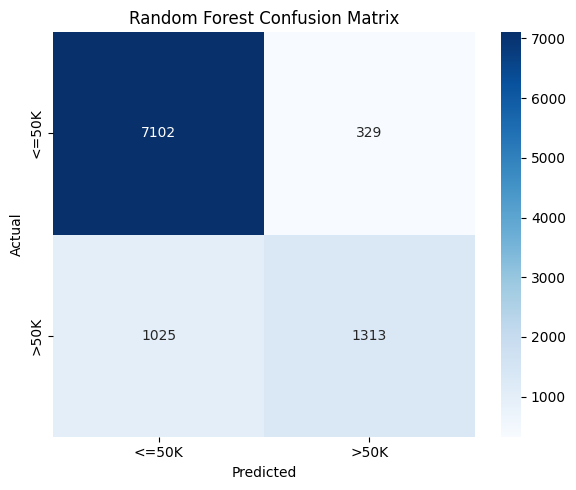

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = results["confusion_matrix"]

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["<=50K", ">50K"],
    yticklabels=["<=50K", ">50K"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

### Confusion Matrix:
True negatives represent correctly classified lower income individuals
True positives represent correctly classified higher income individuals
False negatives are higher income individuals predicted as lower income
False positives are lower income individuals predicted as higher income

Most errors come from false negatives in the higher income class, which is expected given overlapping feature patterns and limited signal for high income prediction in the dataset.

### Key Findings and Evaluation

Overall accuracy provides a high level view of model performance, but the classification report and confusion matrix reveal class specific behavior.

The model performs very strongly on the lower income class, which dominates the dataset. Performance on the higher income class is weaker, reflecting both class imbalance and greater heterogeneity in high income patterns.

Despite this, Random Forest improves stability and reduces variance compared to a single tree by averaging across many diverse decision boundaries. As we see that it achieves an accuracy of *0.86* roughly



In [10]:
importances = get_feature_importances(model, X.columns.tolist())
importances.head(20)


,feature,importance
0,marital_status_Married-civ-spouse,0.167967
1,capital_gain,0.165086
2,education_num,0.116487
3,age,0.076222
4,marital_status_Never-married,0.073311
5,hours_per_week,0.048644
6,relationship_Not-in-family,0.038683
7,capital_loss,0.038400
8,occupation_Exec-managerial,0.030868
9,sex_Male,0.027289


### Feature importance

Random Forest feature importance measures how much each feature contributes to reducing impurity across all trees in the ensemble.

The top features align with economic intuition, including marital status, capital gains, education level, age, and hours worked per week.

These rankings provide directional insight into which attributes matter most, though correlated features may share importance.

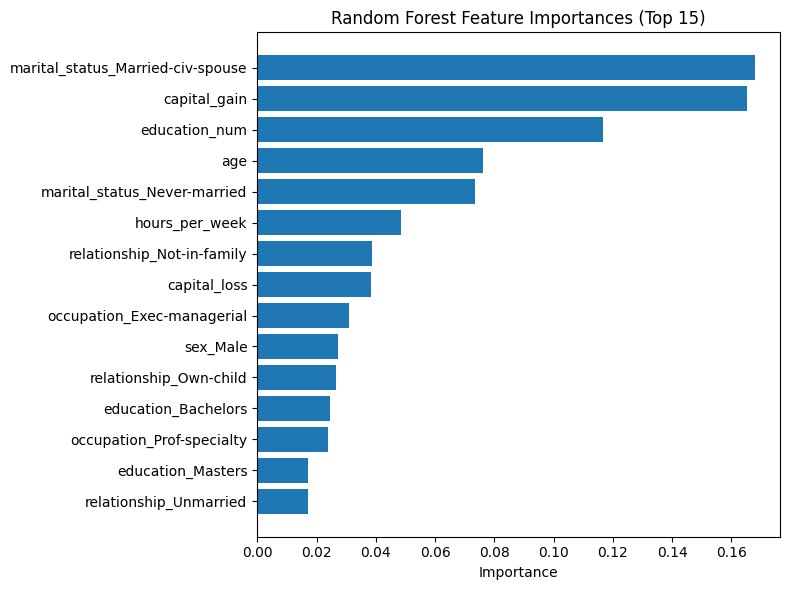

In [11]:
top_k = 15
top = importances.head(top_k).iloc[::-1]

plt.figure(figsize=(8, 6))
plt.barh(top["feature"], top["importance"])
plt.xlabel("Importance")
plt.title(f"Random Forest Feature Importances (Top {top_k})")
plt.tight_layout()
plt.show()


### Conclusion

Random Forest provides a strong and stable classifier for the Census Income dataset. By aggregating many trees, it reduces overfitting and produces more reliable predictions than a single model.

The results show high overall accuracy and meaningful feature importance rankings, while also highlighting the inherent difficulty of predicting higher income outcomes using limited demographic data.

This makes Random Forest a practical and interpretable choice for structured, imbalanced tabular problems like census income prediction.